In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_sessions = pd.read_csv("data/sessions.csv")
df_events = pd.read_csv("data/events.csv")

print(f"loaded {len(df_events)} events!")
display(df_events.head())

loaded 50 events!


,event_id,session_id,event_timestamp,event_type,viewed_category,android_error
0,019ed5f9-0aa3-7550-8dde-8efd605eda88,019ed5f90a9b7180a3cefbcb823f41de,2023-01-30 08:13:43,view_item,Electronics,NaN
1,019ed5f9-0aa3-7550-8dde-8f0eb3ff070c,019ed5f90a9b7180a3cefbcb823f41de,2023-01-30 08:13:47,view_item,Home Goods,NaN
2,019ed5f9-0aa3-7550-8dde-8f17fc052f30,019ed5f90a9b7180a3cefbcb823f41de,2023-01-30 08:13:53,drop_off,Home Goods,ERR_SESSION_TIMEOUT
3,019ed5f9-0aa3-7550-8dde-90cee76b9c2e,019ed5f90a9b7180a3cefc7b331bdba3,2023-02-15 01:07:29,add_to_cart,Electronics,NaN
4,019ed5f9-0aa3-7550-8dde-90b127e1dce1,019ed5f90a9b7180a3cefc7b331bdba3,2023-02-15 01:07:29,view_item,Electronics,NaN


In [11]:
funnel_counts = df_events['event_type'].value_counts()

print("Raw Event Counts:")
display(funnel_counts)

Raw Event Counts:


event_type
view_item         27
add_to_cart       10
begin_checkout     7
drop_off           4
purchase           2
Name: count, dtype: int64

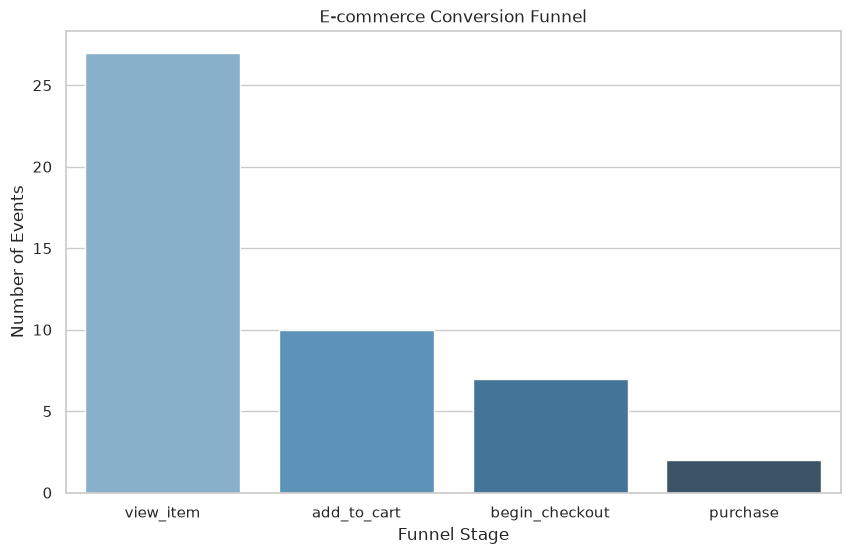

In [12]:
funnel_order = ["view_item", "add_to_cart", "begin_checkout", "purchase"]

ordered_funnel = funnel_counts.reindex(funnel_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=ordered_funnel.index, y=ordered_funnel.values, hue=ordered_funnel.index, palette="Blues_d", legend=False)
plt.title("E-commerce Conversion Funnel")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()

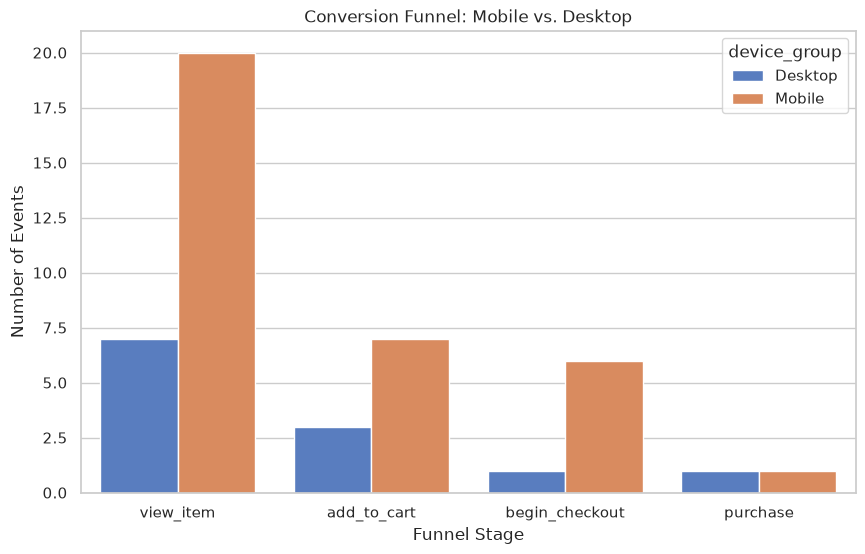

In [14]:
df_merged = df_events.merge(df_sessions[['session_id', 'device_group']], on='session_id', how='left')

device_funnel = df_merged.groupby(['device_group', 'event_type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=device_funnel, 
    x='event_type', 
    y='count', 
    hue='device_group', 
    order=funnel_order, 
    palette="muted"
)
plt.title("Conversion Funnel: Mobile vs. Desktop")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()